# Quarterly Data Pipeline

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Data Ingestion & Cleaning

In [2]:
df = pd.read_csv('Cleaned_Sales.csv')
df.dropna(inplace=True)
df['Net Sales'] = df['Net Sales'].replace(r'[\$, ]', '', regex=True).astype(float)

## 2. Aggregation

In [3]:
summary = df.groupby('Category')['Net Sales'].sum().reset_index()
summary = summary.sort_values(by='Net Sales', ascending=False)
summary.to_csv('Sales_Summary.csv', index=False)

## 3. Data Visualization

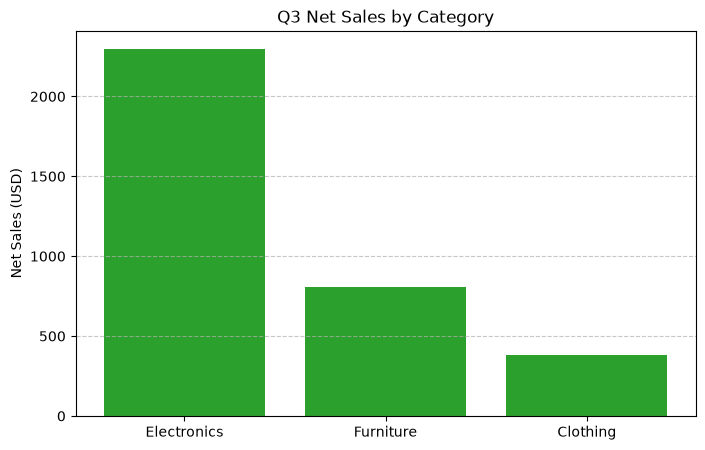

In [4]:
plt.figure(figsize=(8,5))
plt.bar(summary['Category'], summary['Net Sales'], color='#2ca02c')
plt.title('Q3 Net Sales by Category')
plt.ylabel('Net Sales (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('Bar_Chart.png', bbox_inches='tight')

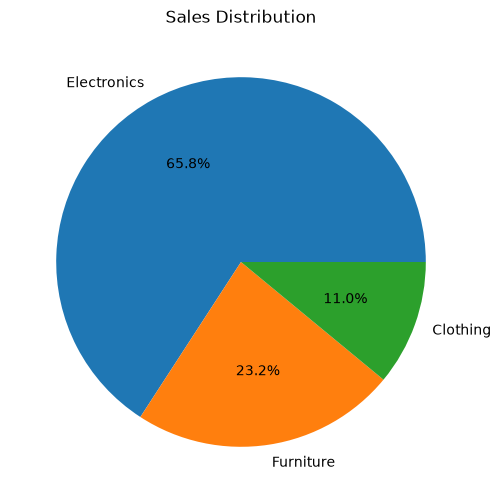

In [5]:
plt.figure(figsize=(6,6))
plt.pie(summary['Net Sales'], labels=summary['Category'], autopct='%1.1f%%')
plt.title('Sales Distribution')
plt.savefig('Pie_Chart.png', bbox_inches='tight')